# Learning 6: Conditional Edges

**Goal**: Create graphs that take different paths based on conditions

## What You'll Learn
- Adding conditional routing to graphs
- Writing router functions
- Creating branching workflows

In [1]:
from dotenv import load_dotenv
load_dotenv()

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from IPython.display import Image, display

print("Setup complete!")

/Users/syedraza/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Setup complete!


## Why Conditional Edges?

Real workflows aren't always linear. Sometimes you need to:
- Take different paths based on user input
- Skip steps if certain conditions aren't met
- Route to different handlers based on classification

```
                    ┌─→ [Handle A] ─→ [END]
[START] → [Check] ──┤
                    └─→ [Handle B] ─→ [END]
```

## Example 1: Simple Yes/No Router

In [2]:
class AgeState(TypedDict):
    age: int
    message: str

def check_age(state: AgeState) -> dict:
    """Just pass through - the routing happens in the edge."""
    return state

def adult_path(state: AgeState) -> dict:
    return {"message": "Welcome! You can access all content."}

def minor_path(state: AgeState) -> dict:
    return {"message": "Welcome! Some content may be restricted."}

# Router function - decides which path to take
def route_by_age(state: AgeState) -> str:
    if state["age"] >= 18:
        return "adult"
    else:
        return "minor"

In [3]:
# Build the graph
builder = StateGraph(AgeState)

# Add nodes
builder.add_node("check", check_age)
builder.add_node("adult", adult_path)
builder.add_node("minor", minor_path)

# Add edges
builder.add_edge(START, "check")

# Add CONDITIONAL edge from check node
builder.add_conditional_edges(
    "check",           # From this node
    route_by_age,      # Use this function to decide
    {                  # Map return values to nodes
        "adult": "adult",
        "minor": "minor"
    }
)

builder.add_edge("adult", END)
builder.add_edge("minor", END)

app = builder.compile()

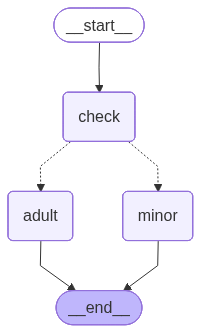

In [4]:
# Visualize
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except:
    print(app.get_graph().draw_ascii())

In [ ]:
# Test with different ages
result1 = app.invoke({"age": 25, "message": ""})
print("Age 25:", result1["message"])

result2 = app.invoke({"age": 15, "message": ""})
print("Age 15:", result2["message"])

## Example 2: Multi-Way Router (Classification)

In [ ]:
class TicketState(TypedDict):
    issue: str
    category: str
    response: str

def classify_ticket(state: TicketState) -> dict:
    """Classify the ticket based on keywords."""
    issue = state["issue"].lower()
    
    if "password" in issue or "login" in issue:
        return {"category": "auth"}
    elif "payment" in issue or "bill" in issue:
        return {"category": "billing"}
    elif "bug" in issue or "error" in issue:
        return {"category": "technical"}
    else:
        return {"category": "general"}

def handle_auth(state: TicketState) -> dict:
    return {"response": "Auth Team: Please reset your password at /reset"}

def handle_billing(state: TicketState) -> dict:
    return {"response": "Billing Team: We'll review your account within 24 hours"}

def handle_technical(state: TicketState) -> dict:
    return {"response": "Tech Support: Please provide error logs"}

def handle_general(state: TicketState) -> dict:
    return {"response": "Support: We'll get back to you soon"}

def route_ticket(state: TicketState) -> str:
    return state["category"]

In [ ]:
# Build the graph
builder = StateGraph(TicketState)

builder.add_node("classify", classify_ticket)
builder.add_node("auth", handle_auth)
builder.add_node("billing", handle_billing)
builder.add_node("technical", handle_technical)
builder.add_node("general", handle_general)

builder.add_edge(START, "classify")

builder.add_conditional_edges(
    "classify",
    route_ticket,
    {
        "auth": "auth",
        "billing": "billing",
        "technical": "technical",
        "general": "general"
    }
)

# All handlers go to END
builder.add_edge("auth", END)
builder.add_edge("billing", END)
builder.add_edge("technical", END)
builder.add_edge("general", END)

app = builder.compile()

In [ ]:
# Visualize
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except:
    print(app.get_graph().draw_ascii())

In [ ]:
# Test different tickets
tickets = [
    "I can't login to my account",
    "There's an error in my payment",
    "I found a bug in the app",
    "How do I change my profile?"
]

for ticket in tickets:
    result = app.invoke({"issue": ticket, "category": "", "response": ""})
    print(f"Issue: {ticket}")
    print(f"Category: {result['category']}")
    print(f"Response: {result['response']}")
    print("---")

## Example 3: Routing to END

Sometimes you want to skip remaining nodes entirely.

In [ ]:
class ValidationState(TypedDict):
    email: str
    is_valid: bool
    result: str

def validate_email(state: ValidationState) -> dict:
    """Check if email is valid."""
    email = state["email"]
    is_valid = "@" in email and "." in email
    return {"is_valid": is_valid}

def process_email(state: ValidationState) -> dict:
    return {"result": f"Email {state['email']} has been processed!"}

def reject_email(state: ValidationState) -> dict:
    return {"result": f"Invalid email: {state['email']}"}

def check_valid(state: ValidationState) -> str:
    if state["is_valid"]:
        return "process"
    else:
        return "reject"

In [ ]:
builder = StateGraph(ValidationState)

builder.add_node("validate", validate_email)
builder.add_node("process", process_email)
builder.add_node("reject", reject_email)

builder.add_edge(START, "validate")
builder.add_conditional_edges("validate", check_valid)
builder.add_edge("process", END)
builder.add_edge("reject", END)

app = builder.compile()

# Test
print(app.invoke({"email": "test@example.com", "is_valid": False, "result": ""}))
print(app.invoke({"email": "invalid-email", "is_valid": False, "result": ""}))

## Using Literal Types for Better Type Safety

In [ ]:
from typing import Literal

# Type-safe router
def typed_router(state: AgeState) -> Literal["adult", "minor"]:
    """Return type explicitly states the possible values."""
    if state["age"] >= 18:
        return "adult"
    return "minor"

# This helps catch errors at development time!

## Exercise: Build a Quiz Router

Create a graph that:
1. Takes a quiz score (0-100)
2. Routes to different feedback nodes based on score:
   - 90+: "Excellent"
   - 70-89: "Good"
   - 50-69: "Needs Improvement"
   - Below 50: "Please Retry"

In [ ]:
# Your code here!



## Key Takeaways

1. `add_conditional_edges()` enables branching
2. Router functions return a string that maps to a node name
3. The mapping dict connects router outputs to actual nodes
4. Use `Literal` types for type safety
5. You can route directly to `END` to skip nodes

**Next**: Learning 7 - Loops in Graphs